# JPMorgan and Chase - Financial Analysis
Focus: Revenue, Trend Analysis, and EPS Trends.

Libraries: matplotlib and seaborn

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import warnings
import matplotlib.ticker as mticker

In [3]:
# Setting the Chart style

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Blues_d", font= "Dejavu Sans")
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})


# ── Colour palette ────────────────────────────────────────
JPM_BLUE       = '#1F4E79'
JPM_MID_BLUE   = '#2E75B6'
JPM_LIGHT_BLUE = '#9DC3E6'
JPM_GOLD       = '#C9A84C'
JPM_RED        = '#C00000'
JPM_GREEN      = '#375623'

OUTPUT_DIR = './charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete. Ready to create charts.")

Setup complete. Ready to create charts.


# Loading Data 

In [12]:
income =  pd.read_csv('data/income_statements')
per_share = pd.read_csv('data/per_share')
ratios = pd.read_csv('data/financial_ratios')

print(income.head())
print("Data loaded successfully.")

# Convert them to billions for readable chart labels
money_cols = ['total_revenue', 'net_interest_income', 'non_interest_revenue', 'non_interest_expense', 'net_income', 'provision_credit_loss']

for col in money_cols:
    income[col + '_B'] = income[col] / 1000000

years = income['year'].tolist()

print('Data loaded')
print(f'  Years covered: {years[0]}  {years[-1]}')
income[['year'] + [c + '_B' for c in money_cols]].round(1)

   year  total_revenue  net_interest_income  non_interest_revenue  \
0  2022   1.277270e+11         6.671000e+10                   NaN   
1  2023   1.549520e+11         8.926700e+10                   NaN   
2  2024   1.694390e+11         9.258300e+10                   NaN   
3  2025   1.818470e+11         9.544300e+10                   NaN   

   non_interest_expense  provision_credit_loss    net_income  basic_eps  \
0                   NaN                    NaN  3.767600e+10      12.10   
1                   NaN                    NaN  4.955200e+10      16.25   
2                   NaN                    NaN  5.847100e+10      19.79   
3                   NaN                    NaN  5.704800e+10      20.05   

   diluted_eps  
0        12.09  
1        16.23  
2        19.75  
3        20.02  
Data loaded successfully.
Data loaded
  Years covered: 2022  2025


,year,total_revenue_B,net_interest_income_B,non_interest_revenue_B,non_interest_expense_B,net_income_B,provision_credit_loss_B
0,2022,127727.0,66710.0,NaN,NaN,37676.0,NaN
1,2023,154952.0,89267.0,NaN,NaN,49552.0,NaN
2,2024,169439.0,92583.0,NaN,NaN,58471.0,NaN
3,2025,181847.0,95443.0,NaN,NaN,57048.0,NaN


# Revenue Trend Over Time

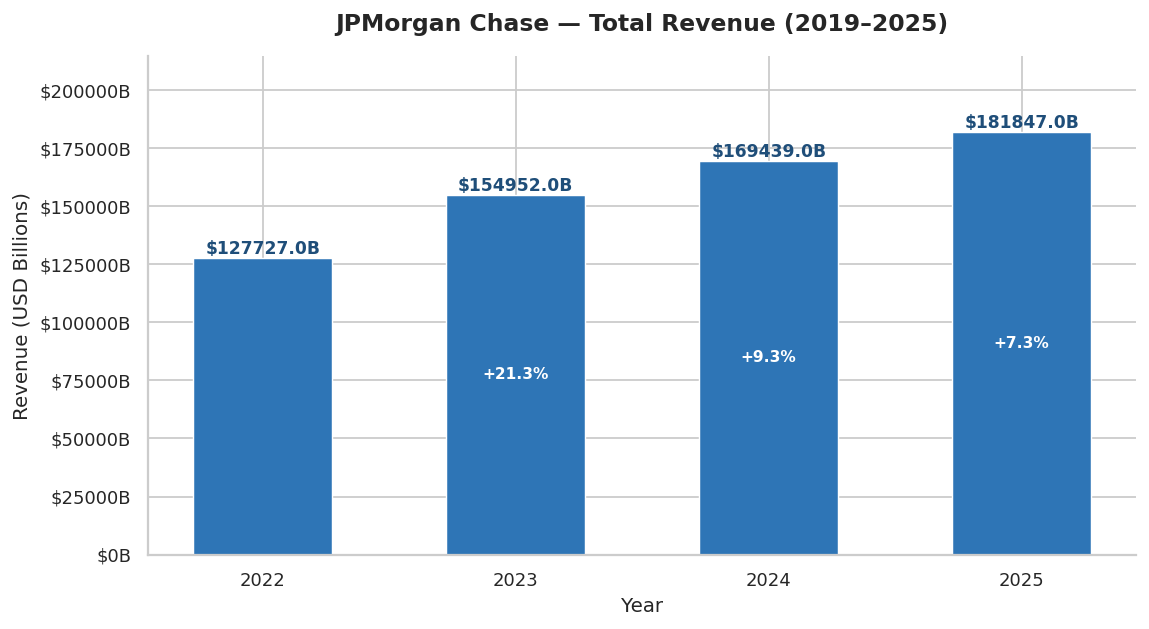

 Chart saved: 01_total_revenue.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    income['year'],
    income['total_revenue_B'],
    color=JPM_MID_BLUE,
    width=0.55,
    edgecolor='white',
    linewidth=0.8
)
# Annotate each bar with the value
for bar, val in zip(bars, income['total_revenue_B']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'${val:.1f}B',
        ha='center', va='bottom',
        fontsize=9.5, fontweight='bold', color=JPM_BLUE
    )

# YoY growth annotations
for i in range(1, len(income)):
    growth = ratios.iloc[i]['revenue_growth_pct']
    color  = JPM_GREEN if growth >= 0 else JPM_RED
    ax.text(
        income['year'].iloc[i],
        income['total_revenue_B'].iloc[i] / 2,
        f'{growth:+.1f}%',
        ha='center', va='center',
        fontsize=8.5, color='white', fontweight='bold'
    )

ax.set_title('JPMorgan Chase — Total Revenue (2019–2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (USD Billions)')
ax.set_xticks(income['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_ylim(0, income['total_revenue_B'].max() * 1.18)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_total_revenue.png', bbox_inches='tight')
plt.show()
print(' Chart saved: 01_total_revenue.png')

ValueError: Axis limits cannot be NaN or Inf

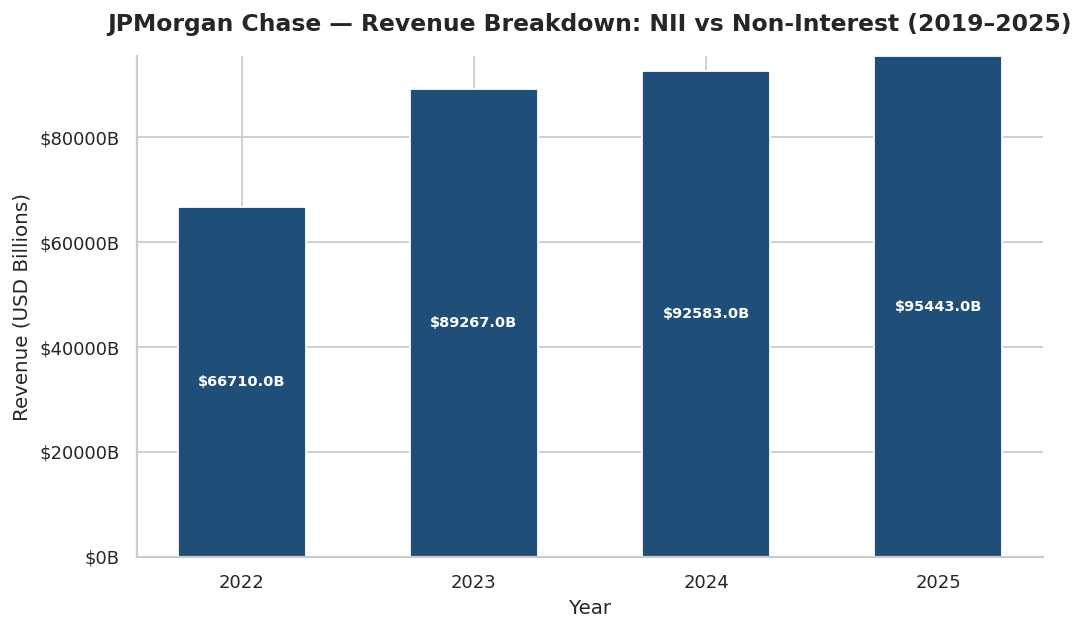

In [18]:
# ── Stacked bar: NII vs Non-Interest Revenue ──────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    income['year'],
    income['net_interest_income_B'],
    label='Net Interest Income',
    color=JPM_BLUE,
    width=0.55,
    edgecolor='white'
)
ax.bar(
    income['year'],
    income['non_interest_revenue_B'],
    bottom=income['net_interest_income_B'],
    label='Non-Interest Revenue',
    color=JPM_LIGHT_BLUE,
    width=0.55,
    edgecolor='white'
)

# Label each segment
for i, row in income.iterrows():
    ax.text(row['year'], row['net_interest_income_B'] / 2,
            f"${row['net_interest_income_B']:.1f}B",
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(row['year'],
            row['net_interest_income_B'] + row['non_interest_revenue_B'] / 2,
            f"${row['non_interest_revenue_B']:.1f}B",
            ha='center', va='center', fontsize=8, color=JPM_BLUE, fontweight='bold')

ax.set_title('JPMorgan Chase — Revenue Breakdown: NII vs Non-Interest (2019–2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (USD Billions)')
ax.set_xticks(income['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_ylim(0, (income['net_interest_income_B'] + income['non_interest_revenue_B']).max() * 1.12)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_revenue_breakdown.png', bbox_inches='tight')
plt.show()
print(' Chart saved: 02_revenue_breakdown.png')

In [19]:
# ── Revenue insight summary ───────────────────────────────
nii_share = (income['net_interest_income_B'] / income['total_revenue_B'] * 100).round(1)
print('Net Interest Income as % of Total Revenue:')
for yr, pct in zip(years, nii_share):
    bar = '█' * int(pct / 2)
    print(f'  {yr}: {bar} {pct:.1f}%')
print()
print(f' NII share jumped from {nii_share.iloc[0]:.1f}% (2019) to {nii_share.iloc[-1]:.1f}% (2025)')
print(f'   → Driven by rising interest rates from 2022 onwards (Fed rate hikes)')

Net Interest Income as % of Total Revenue:
  2022: ██████████████████████████ 52.2%
  2023: ████████████████████████████ 57.6%
  2024: ███████████████████████████ 54.6%
  2025: ██████████████████████████ 52.5%

 NII share jumped from 52.2% (2019) to 52.5% (2025)
   → Driven by rising interest rates from 2022 onwards (Fed rate hikes)


# Net Income Trend
Net Income is what is left after expenses, provisions and taxes are removed

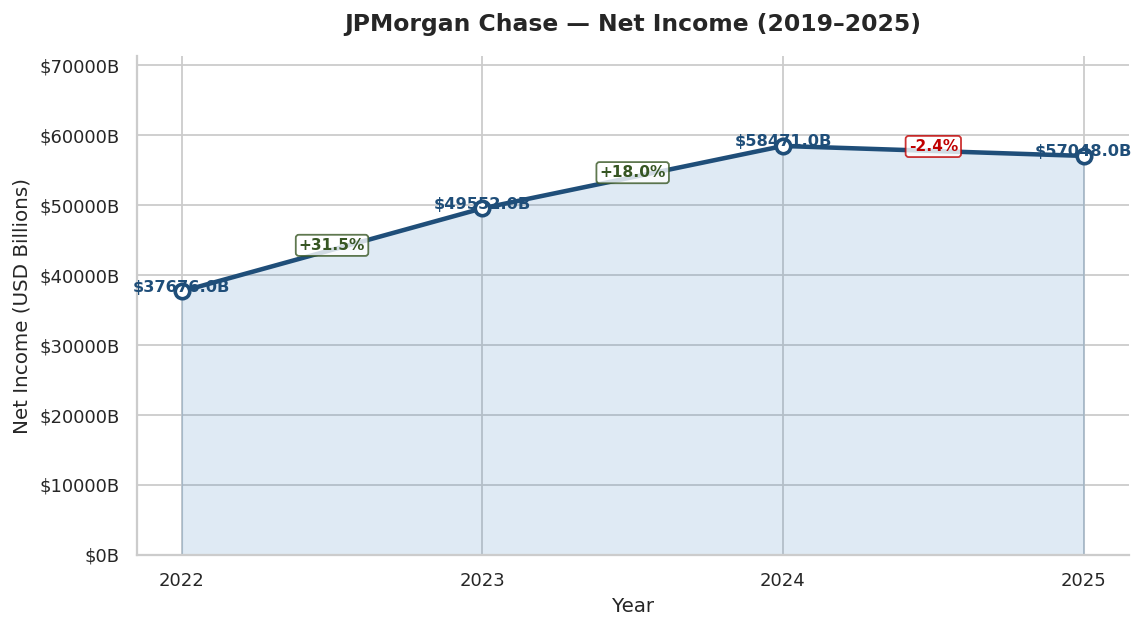

 Chart saved: 03_net_income.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

# Line + area fill
ax.fill_between(
    income['year'],
    income['net_income_B'],
    alpha=0.15, color=JPM_MID_BLUE
)
ax.plot(
    income['year'],
    income['net_income_B'],
    color=JPM_BLUE, linewidth=2.5, marker='o',
    markersize=8, markerfacecolor='white',
    markeredgecolor=JPM_BLUE, markeredgewidth=2
)

# Value labels above each point
for _, row in income.iterrows():
    ax.text(
        row['year'], row['net_income_B'] + 1.2,
        f"${row['net_income_B']:.1f}B",
        ha='center', fontsize=9, fontweight='bold', color=JPM_BLUE
    )

# YoY growth labels between points
for i in range(1, len(income)):
    growth = ratios.iloc[i]['net_income_growth_pct']
    mid_x  = (income['year'].iloc[i-1] + income['year'].iloc[i]) / 2
    mid_y  = (income['net_income_B'].iloc[i-1] + income['net_income_B'].iloc[i]) / 2
    color  = JPM_GREEN if growth >= 0 else JPM_RED
    ax.text(
        mid_x, mid_y - 3,
        f'{growth:+.1f}%',
        ha='center', fontsize=8.5, color=color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.8)
    )

ax.set_title('JPMorgan Chase — Net Income (2019–2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Net Income (USD Billions)')
ax.set_xticks(income['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_ylim(0, income['net_income_B'].max() * 1.22)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_net_income.png', bbox_inches='tight')
plt.show()
print(' Chart saved: 03_net_income.png')

# Net Income vs Non Income Expense

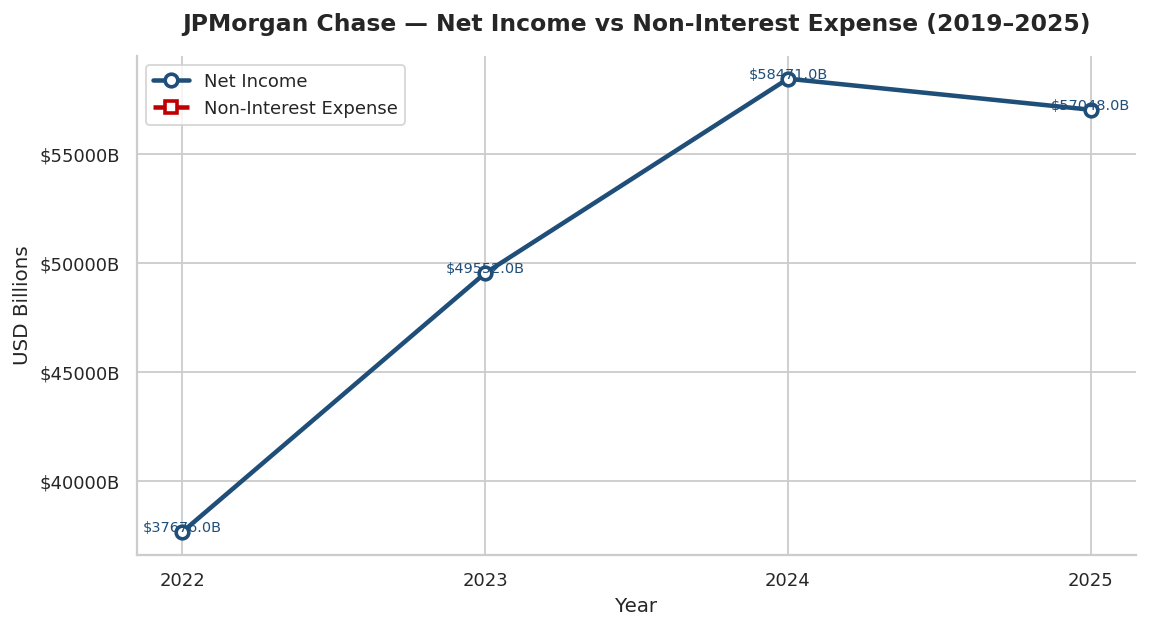

Chart saved: 04_income_vs_expense.png


In [24]:
# ── Net Income vs Non-Interest Expense — cost discipline check ──
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    income['year'], income['net_income_B'],
    color=JPM_BLUE, linewidth=2.5, marker='o',
    markersize=7, markerfacecolor='white',
    markeredgecolor=JPM_BLUE, markeredgewidth=2,
    label='Net Income'
)
ax.plot(
    income['year'], income['non_interest_expense_B'],
    color=JPM_RED, linewidth=2.5, marker='s',
    markersize=7, markerfacecolor='white',
    markeredgecolor=JPM_RED, markeredgewidth=2,
    label='Non-Interest Expense', linestyle='--'
)

# Value labels
for _, row in income.iterrows():
    ax.text(row['year'], row['net_income_B'] + 1,
            f"${row['net_income_B']:.1f}B",
            ha='center', fontsize=8, color=JPM_BLUE)
    ax.text(row['year'], row['non_interest_expense_B'] + 1,
            f"${row['non_interest_expense_B']:.1f}B",
            ha='center', fontsize=8, color=JPM_RED)

ax.set_title('JPMorgan Chase — Net Income vs Non-Interest Expense (2019–2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('USD Billions')
ax.set_xticks(income['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_income_vs_expense.png', bbox_inches='tight')
plt.show()
print('Chart saved: 04_income_vs_expense.png')

# EPS Trend 
Earnings Per Share shows profitability from a shareholders perspective.

We will plot Basic EPS and Diluted EPS side by side - the gap between them shows them reveals how much dilution exists from stock-based compensation.

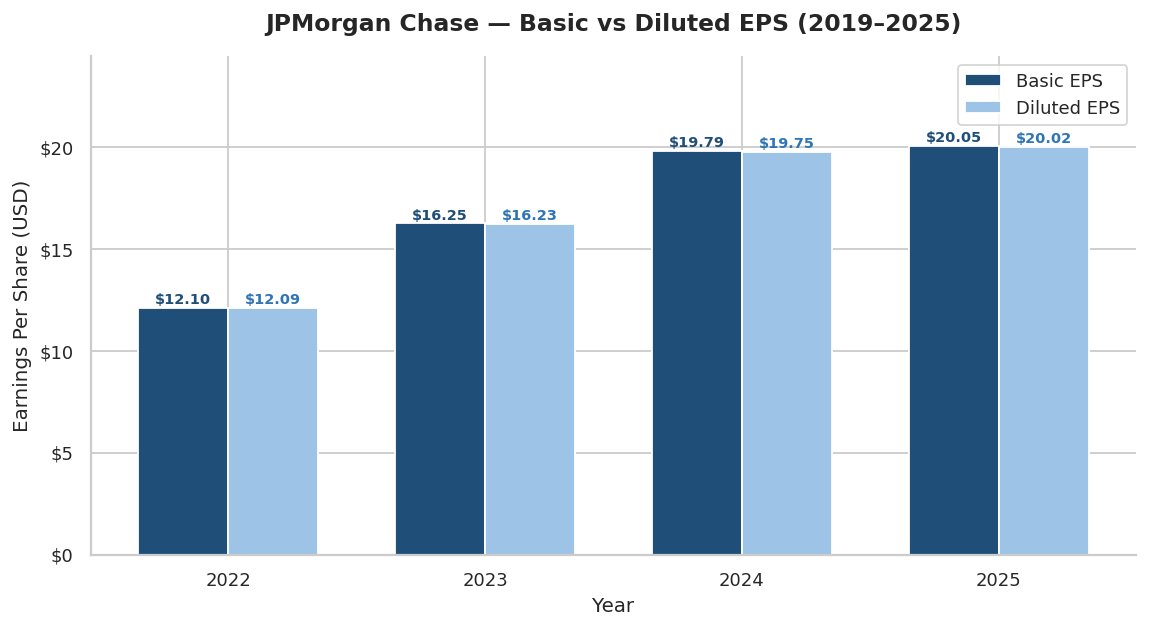

Chart saved: 05_eps_basic_vs_diluted.png


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

x      = range(len(years))
width  = 0.35

bars_basic   = ax.bar([i - width/2 for i in x], income['basic_eps'],
                      width=width, label='Basic EPS',
                      color=JPM_BLUE, edgecolor='white')
bars_diluted = ax.bar([i + width/2 for i in x], income['diluted_eps'],
                      width=width, label='Diluted EPS',
                      color=JPM_LIGHT_BLUE, edgecolor='white')

# Value labels
for bar in bars_basic:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"${bar.get_height():.2f}",
            ha='center', fontsize=8, color=JPM_BLUE, fontweight='bold')
for bar in bars_diluted:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"${bar.get_height():.2f}",
            ha='center', fontsize=8, color=JPM_MID_BLUE, fontweight='bold')

ax.set_title('JPMorgan Chase — Basic vs Diluted EPS (2019–2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Earnings Per Share (USD)')
ax.set_xticks(list(x))
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
ax.set_ylim(0, income['basic_eps'].max() * 1.22)
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_eps_basic_vs_diluted.png', bbox_inches='tight')
plt.show()
print('Chart saved: 05_eps_basic_vs_diluted.png')

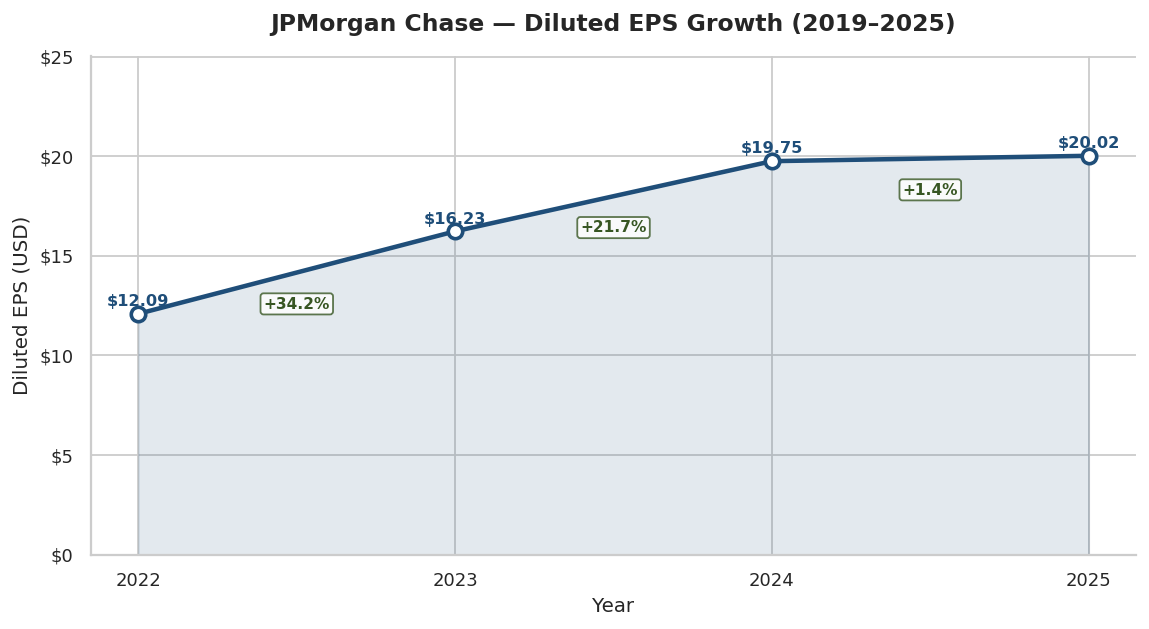

Chart saved: 06_diluted_eps_growth.png


In [27]:
# ── Diluted EPS growth line ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(income['year'], income['diluted_eps'],
                alpha=0.12, color=JPM_BLUE)
ax.plot(income['year'], income['diluted_eps'],
        color=JPM_BLUE, linewidth=2.5, marker='o',
        markersize=8, markerfacecolor='white',
        markeredgecolor=JPM_BLUE, markeredgewidth=2,
        label='Diluted EPS')

# Value labels
for _, row in income.iterrows():
    ax.text(row['year'], row['diluted_eps'] + 0.4,
            f"${row['diluted_eps']:.2f}",
            ha='center', fontsize=9, fontweight='bold', color=JPM_BLUE)

# YoY growth labels
for i in range(1, len(income)):
    growth = ratios.iloc[i]['eps_growth_pct']
    mid_x  = (income['year'].iloc[i-1] + income['year'].iloc[i]) / 2
    mid_y  = (income['diluted_eps'].iloc[i-1] + income['diluted_eps'].iloc[i]) / 2
    color  = JPM_GREEN if growth >= 0 else JPM_RED
    ax.text(mid_x, mid_y - 1.8,
            f'{growth:+.1f}%',
            ha='center', fontsize=8.5, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.8))

ax.set_title('JPMorgan Chase — Diluted EPS Growth (2019–2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Diluted EPS (USD)')
ax.set_xticks(income['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
ax.set_ylim(0, income['diluted_eps'].max() * 1.25)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_diluted_eps_growth.png', bbox_inches='tight')
plt.show()
print('Chart saved: 06_diluted_eps_growth.png')

# Summary Dashboard

A 2 by 2 figure combining all four key trend charts into one view - useful for reports and representations

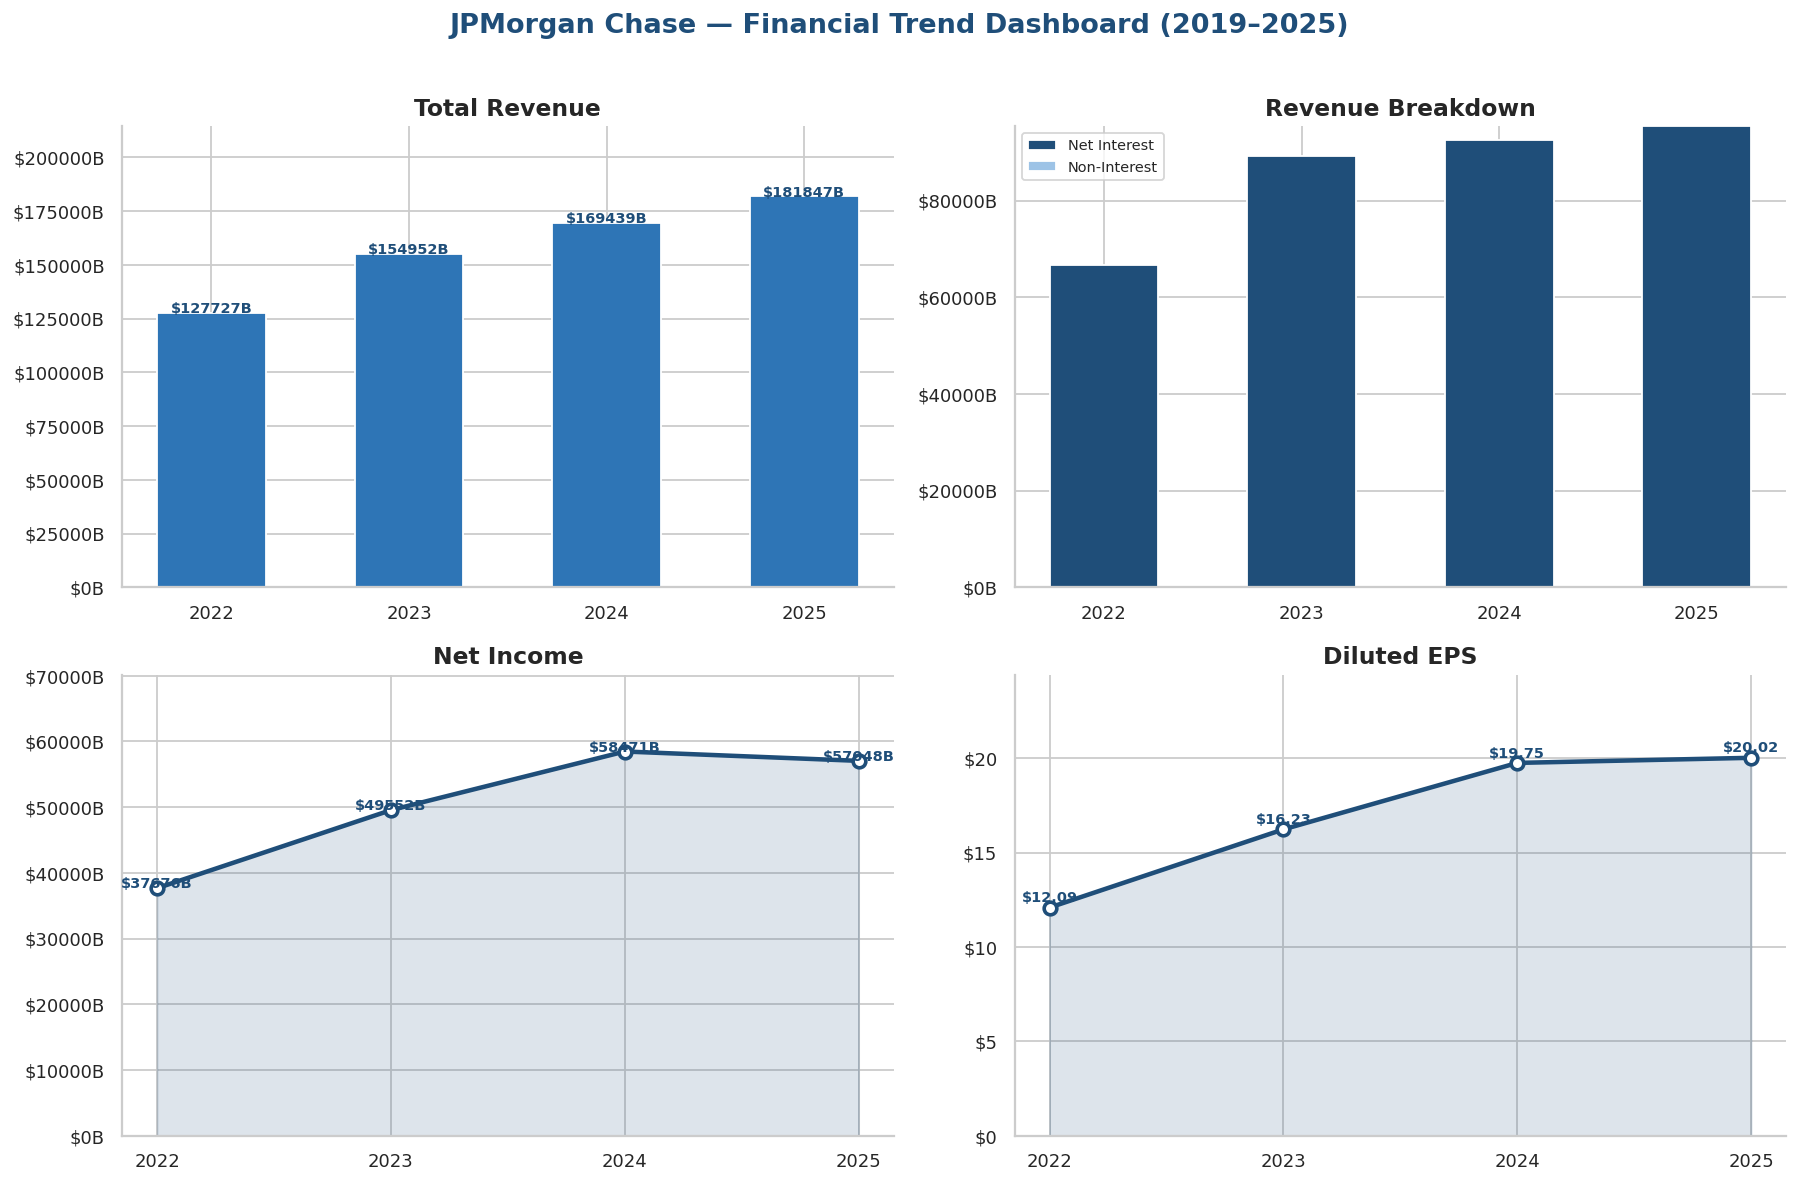

 Chart saved: 07_summary_dashboard.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('JPMorgan Chase — Financial Trend Dashboard (2019–2025)',
             fontsize=15, fontweight='bold', color=JPM_BLUE, y=1.01)

# ── Panel 1: Total Revenue ────────────────────────────────
ax1 = axes[0, 0]
bars = ax1.bar(income['year'], income['total_revenue_B'],
               color=JPM_MID_BLUE, width=0.55, edgecolor='white')
for bar, val in zip(bars, income['total_revenue_B']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'${val:.0f}B', ha='center', fontsize=8, fontweight='bold', color=JPM_BLUE)
ax1.set_title('Total Revenue')
ax1.set_xticks(income['year'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax1.set_ylim(0, income['total_revenue_B'].max() * 1.18)
sns.despine(ax=ax1, top=True, right=True)

# ── Panel 2: NII vs Non-Interest Stacked ─────────────────
ax2 = axes[0, 1]
ax2.bar(income['year'], income['net_interest_income_B'],
        color=JPM_BLUE, width=0.55, label='Net Interest', edgecolor='white')
ax2.bar(income['year'], income['non_interest_revenue_B'],
        bottom=income['net_interest_income_B'],
        color=JPM_LIGHT_BLUE, width=0.55, label='Non-Interest', edgecolor='white')
ax2.set_title('Revenue Breakdown')
ax2.set_xticks(income['year'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax2.legend(fontsize=8, loc='upper left')
sns.despine(ax=ax2, top=True, right=True)

# ── Panel 3: Net Income ───────────────────────────────────
ax3 = axes[1, 0]
ax3.fill_between(income['year'], income['net_income_B'], alpha=0.15, color=JPM_BLUE)
ax3.plot(income['year'], income['net_income_B'],
         color=JPM_BLUE, linewidth=2.5, marker='o',
         markersize=7, markerfacecolor='white',
         markeredgecolor=JPM_BLUE, markeredgewidth=2)
for _, row in income.iterrows():
    ax3.text(row['year'], row['net_income_B'] + 0.8,
             f"${row['net_income_B']:.0f}B",
             ha='center', fontsize=8, fontweight='bold', color=JPM_BLUE)
ax3.set_title('Net Income')
ax3.set_xticks(income['year'])
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax3.set_ylim(0, income['net_income_B'].max() * 1.2)
sns.despine(ax=ax3, top=True, right=True)

# ── Panel 4: Diluted EPS ──────────────────────────────────
ax4 = axes[1, 1]
ax4.fill_between(income['year'], income['diluted_eps'], alpha=0.15, color=JPM_BLUE)
ax4.plot(income['year'], income['diluted_eps'],
         color=JPM_BLUE, linewidth=2.5, marker='o',
         markersize=7, markerfacecolor='white',
         markeredgecolor=JPM_BLUE, markeredgewidth=2)
for _, row in income.iterrows():
    ax4.text(row['year'], row['diluted_eps'] + 0.3,
             f"${row['diluted_eps']:.2f}",
             ha='center', fontsize=8, fontweight='bold', color=JPM_BLUE)
ax4.set_title('Diluted EPS')
ax4.set_xticks(income['year'])
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
ax4.set_ylim(0, income['diluted_eps'].max() * 1.22)
sns.despine(ax=ax4, top=True, right=True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_summary_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Chart saved: 07_summary_dashboard.png')

# Key Takeaways

Key Insights

In [33]:
rev_growth  = ((income['total_revenue_B'].iloc[-1] / income['total_revenue_B'].iloc[0]) - 1) * 100
ni_growth   = ((income['net_income_B'].iloc[-1]    / income['net_income_B'].iloc[0])    - 1) * 100
eps_growth  = ((income['diluted_eps'].iloc[-1]     / income['diluted_eps'].iloc[0])     - 1) * 100
nii_2019    = (income['net_interest_income_B'].iloc[0]  / income['total_revenue_B'].iloc[0]  * 100)
nii_2024    = (income['net_interest_income_B'].iloc[-1] / income['total_revenue_B'].iloc[-1] * 100)

print('=' * 60)
print('  KEY TAKEAWAYS — JPMorgan Chase 2019–2024')
print('=' * 60)
print(f'   Total Revenue grew      {rev_growth:+.1f}%  over 5 years')
print(f'   Net Income grew         {ni_growth:+.1f}%  over 5 years')
print(f'   Diluted EPS grew        {eps_growth:+.1f}%  over 5 years')
print(f'   NII share of revenue:   {nii_2019:.1f}% (2019) → {nii_2024:.1f}% (2025)')
print()
print('  Notable events visible in the data:')
print('  • 2020: Net income dropped -20% — COVID-19 loan loss provisions')
print('  • 2021: Strong rebound +66%  — provisions reversed, markets recovered')
print('  • 2022: Declined -22%        — market volatility, investment banking slowdown')
print('  • 2023-25: New records       — Fed rate hikes boosted NII significantly')


  KEY TAKEAWAYS — JPMorgan Chase 2019–2024
   Total Revenue grew      +42.4%  over 5 years
   Net Income grew         +51.4%  over 5 years
   Diluted EPS grew        +65.6%  over 5 years
   NII share of revenue:   52.2% (2019) → 52.5% (2025)

  Notable events visible in the data:
  • 2020: Net income dropped -20% — COVID-19 loan loss provisions
  • 2021: Strong rebound +66%  — provisions reversed, markets recovered
  • 2022: Declined -22%        — market volatility, investment banking slowdown
  • 2023-25: New records       — Fed rate hikes boosted NII significantly
